# Project: Bicycle vs Motorcycle Image Classification

**Course:** Neural Network Project Work
**Authors:** Bächler Domenik, Filippone Dario
**Date:** 29 May 2026

**Step 2 of 2** in this project. This notebook assumes that
`create_dataset.ipynb` has already been run and that a folder
`02_data_clean/` exists with exactly this structure:

```
02_data_clean/
├── bicycle/
└── motorcycle/
```

> **Note on folder names:** the two class folders must be named exactly
> `bicycle` and `motorcycle` (lowercase). If your local copy of
> `02_data_clean/` uses a different name (e.g. `bike/`), rename it before
> running this notebook — the class names are used directly as labels and
> also appear throughout the plots and tables below.

All paths in this notebook are relative to the repository root, so run
Jupyter from the top-level `neune_project/` folder.

## 1. Task and motivation

The goal of this project is to build a binary image classifier that can distinguish **bicycles** from **motorcycles**. Both objects look similar at a glance (two wheels, a frame, a saddle), so the task is a small but non-trivial computer vision problem and a good fit for a convolutional neural network (CNN).

We follow a standard image-classification pipeline:

1. Collect and clean the image data.
2. Run an exploratory data analysis (class balance, image sizes, brightness).
3. Split the data into train / validation / test sets.
4. Train a simple **baseline CNN** from scratch.
5. Compare against a **transfer learning** model (MobileNetV2 pretrained on ImageNet).
6. Evaluate both models on the held-out test set and discuss the results.


As seen in this Paper from [Kennedy et al. 2022](../neune_project/Paper/s12889-022-13075-2-2.pdf), one major problem in traffic, is the compliance of helmet use in motorcyclist. This deep learning model could help, detect motorcyclist (and distinguish) from cyclist better. A reliable distinction between bicycles and motorcycles could serve as a first step in larger traffic-monitoring systems, for example for helmet-detection pipelines.

## 2. Setup


In [1]:
# === Setup and global configuration ===
# This block imports all required libraries and defines every global
# parameter (paths, image size, batch size, epochs) in one central
# place, so it only has to be changed here when something is tweaked.

# Standard library: filesystem, randomness, file operations, counting
import os

# Silence TensorFlow's C++-level logging BEFORE importing tensorflow.
# Without this, every intentionally-discarded corrupted image in the
# cleaning step below triggers a noisy "Local rendezvous is aborting"
# warning on stderr, even though our own try/except already handles it
# correctly. Level '3' = errors only (no INFO/WARNING).
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import random
import shutil
from collections import Counter

# Numerics, plotting and image handling
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Deep-learning framework and helper to split image folders
import tensorflow as tf
tf.get_logger().setLevel("ERROR")  # also silence TF's Python-side logger
import splitfolders

# Reproducibility: same seed for random, numpy and TensorFlow,
# so that training runs are comparable.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Paths: source folder with the cleaned images and output folder for the split.
SOURCE_DIR = "02_data_clean"
SPLIT_DIR = "data_split"

# Model and dataset parameters
IMG_SIZE = (224, 224)   # input size for both the CNN and MobileNetV2
BATCH_SIZE = 32         # number of images per training batch
EPOCHS = 20             # number of training passes over the data

# Image extensions that tf.keras.utils.image_dataset_from_directory accepts reliably
# Only files with these extensions can be decoded safely by TensorFlow.
TF_ALLOWED_EXT = (".jpg", ".jpeg", ".png", ".gif", ".bmp")

# Quick sanity print of the installed TF version.
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.16.1


In [ ]:
# === Sanity check: verify the expected input structure exists ===
# Fails fast with a clear message instead of a confusing error later,
# in case the dataset pipeline (create_dataset.ipynb) was not run yet
# or the class folders were named differently.
EXPECTED_CLASSES = {"bicycle", "motorcycle"}

if not os.path.isdir(SOURCE_DIR):
    raise FileNotFoundError(
        f"'{SOURCE_DIR}' does not exist. Run create_dataset.ipynb first, "
        "or adjust SOURCE_DIR above."
    )

found_classes = {d for d in os.listdir(SOURCE_DIR) if os.path.isdir(os.path.join(SOURCE_DIR, d))}
missing = EXPECTED_CLASSES - found_classes
if missing:
    raise FileNotFoundError(
        f"Expected class folders {EXPECTED_CLASSES} inside '{SOURCE_DIR}', "
        f"but found {found_classes or 'none'}. Missing: {missing}. "
        "Rename your folders to match exactly (case-sensitive)."
    )

print(f"Found expected class folders in '{SOURCE_DIR}':", sorted(found_classes))

## 3. Cleaning the image files

Real-world image datasets are messy. Two helper functions take care of this before training:

1. `convert_webp_to_jpg` re-encodes every `.webp` as a JPEG.
2. `remove_invalid_images_for_tensorflow` deletes files that TensorFlow cannot decode, so the dataset loader does not crash later with `Unknown image file format`.


In [2]:
# === Helper functions for cleaning the image data ===
# Real-world image datasets often contain files that TensorFlow cannot
# process directly (e.g. .webp or corrupted images). The two functions
# below make sure only "clean" files remain before the dataset loader
# is called.

def convert_webp_to_jpg(data_dir):
    """Re-encode every .webp file in data_dir as a JPEG and remove the original."""
    # Counter for files that were successfully converted.
    converted = 0

    # Walk recursively through all sub-folders.
    for root, dirs, files in os.walk(data_dir):
        for file in files:
            # Only look at .webp files (case-insensitive).
            if file.lower().endswith(".webp"):
                old_path = os.path.join(root, file)
                # New path: same filename but with a .jpg extension.
                new_path = os.path.splitext(old_path)[0] + ".jpg"

                try:
                    # Open the image, convert to RGB (JPEG has no alpha channel)
                    # and save it as a high-quality JPEG.
                    with Image.open(old_path) as img:
                        img = img.convert("RGB")
                        img.save(new_path, "JPEG", quality=95)

                    # Remove the original file so no duplicates remain.
                    os.remove(old_path)
                    converted += 1
                    print("Converted:", old_path, "->", new_path)

                except Exception as e:
                    # Report the broken file but keep the script running.
                    print("Could not convert WEBP:", old_path, "|", e)

    # Summary at the end.
    print("Total WEBP files converted:", converted)


def remove_invalid_images_for_tensorflow(data_dir):
    """Delete files TensorFlow cannot decode, so the dataset loader does not crash."""
    # Counters for removed and successfully checked images.
    removed = 0
    checked = 0

    # Again walk recursively through all sub-folders.
    for root, dirs, files in os.walk(data_dir):
        for file in files:
            path = os.path.join(root, file)

            # Remove unsupported file types
            # Files with a disallowed extension are deleted immediately.
            if not file.lower().endswith(TF_ALLOWED_EXT):
                os.remove(path)
                removed += 1
                print("Removed (unsupported extension):", path)
                continue

            # Test the file with TensorFlow itself, since TensorFlow also loads the dataset later
            # Using the exact same decoder as the later training loader
            # guarantees that only files which the real loader can read survive.
            try:
                img_bytes = tf.io.read_file(path)
                _ = tf.io.decode_image(img_bytes, channels=3, expand_animations=False)
                checked += 1

            except Exception:
                # If decoding fails, the file is unusable for us.
                os.remove(path)
                removed += 1
                print("Removed (corrupted):", path)

    # Final stats.
    print("Valid images checked:", checked)
    print("Total removed:", removed)


# Apply both cleanup steps to the source folder.
convert_webp_to_jpg(SOURCE_DIR)
remove_invalid_images_for_tensorflow(SOURCE_DIR)

Total WEBP files converted: 0
Removed (corrupted): 02_data_clean\bicycle\archive (2)_1427d10457.jpg
Removed (corrupted): 02_data_clean\bicycle\archive (2)_19137ccd5e.jpg
Removed (corrupted): 02_data_clean\bicycle\archive (2)_419fc5cb2a.jpg
Removed (corrupted): 02_data_clean\bicycle\archive (2)_47317e09a4.jpg
Removed (corrupted): 02_data_clean\bicycle\archive (2)_55432b58a1.jpg
Removed (corrupted): 02_data_clean\bicycle\archive (2)_61bd987b2c.jpeg
Removed (corrupted): 02_data_clean\bicycle\archive (2)_6d0aafd01f.jpeg
Removed (corrupted): 02_data_clean\bicycle\archive (2)_7d71e773a3.jpeg
Removed (corrupted): 02_data_clean\bicycle\archive (2)_8de7453fa6.jpg
Removed (corrupted): 02_data_clean\bicycle\archive (2)_90c4ae14af.jpeg
Removed (corrupted): 02_data_clean\bicycle\archive (2)_cd2f30e82c.jpg
Removed (corrupted): 02_data_clean\bicycle\archive (2)_d5c7930d48.jpg
Removed (corrupted): 02_data_clean\bicycle\archive (2)_e79fa94447.jpg
Removed (corrupted): 02_data_clean\bicycle\archive (2)_f

## 4. Exploratory data analysis

Before training, we look at four properties of the cleaned dataset:

- **Class distribution:** Is the dataset balanced?
- **Sample images:** Do the labels match what we see?
- **Brightness and image size:** How varied are the images?


### 4.1 Class distribution


Counter({'motorcycle': 235, 'bicycle': 161})


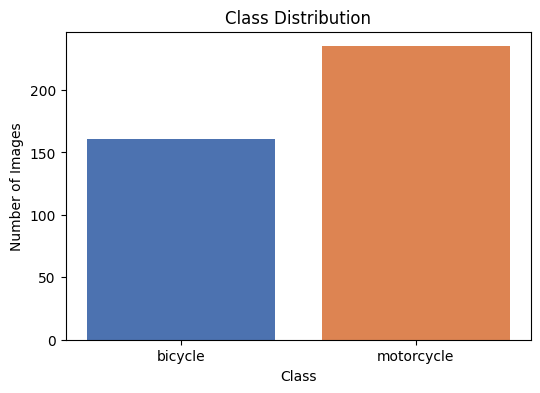

In [3]:
# === Analyse the class distribution ===
# Count the number of valid images per class to see whether the dataset
# is balanced (an imbalance can cause the model to prefer one class).

# List that stores the class name (= folder name) for every valid image.
labels = []

# Iterate over all entries in the source folder (each sub-folder is a class).
for label in os.listdir(SOURCE_DIR):
    class_path = os.path.join(SOURCE_DIR, label)

    # Only consider real sub-folders, skip hidden files etc.
    if os.path.isdir(class_path):
        for file in os.listdir(class_path):
            # Only count files with an allowed image extension.
            if file.lower().endswith(TF_ALLOWED_EXT):
                labels.append(label)

# Counter tallies how often each class name appears.
counter = Counter(labels)
print(counter)

# Bar chart of the class distribution.
plt.figure(figsize=(6, 4))
plt.bar(counter.keys(), counter.values(), color=["#4C72B0", "#DD8452"])
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()

### 4.2 Sample images per class


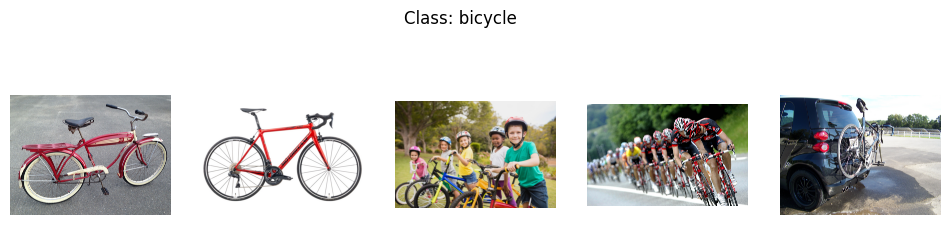

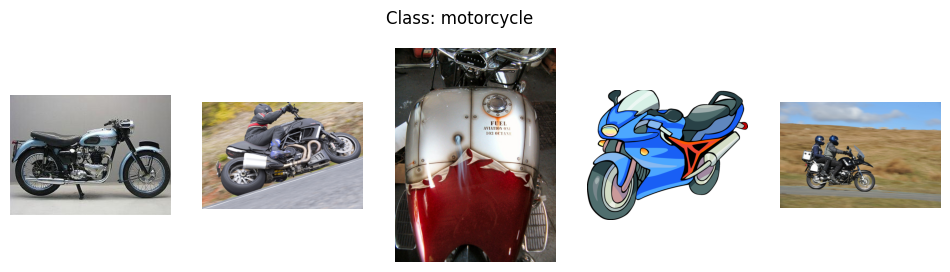

In [27]:
# === Show sample images per class ===
# A visual sanity check: do the folder names match the images inside?
# Mislabeled images are easy to spot this way.

# Number of randomly chosen images to display per class.
samples_per_class = 5

# Iterate over the classes (sub-folders) in alphabetical order.
for label in sorted(os.listdir(SOURCE_DIR)):
    class_path = os.path.join(SOURCE_DIR, label)

    # Skip anything that is not a folder.
    if not os.path.isdir(class_path):
        continue

    # Collect all valid image files in the class.
    images = [f for f in os.listdir(class_path) if f.lower().endswith(TF_ALLOWED_EXT)]
    if len(images) == 0:
        # Empty classes would cause errors -> just print a hint.
        print("No valid images in:", class_path)
        continue

    # Random selection (at most as many as exist, to avoid an IndexError).
    sample_images = random.sample(images, min(samples_per_class, len(images)))

    # One figure per class, with the class name as the suptitle.
    plt.figure(figsize=(12, 3))
    plt.suptitle(f"Class: {label}")

    # Show each sample image in its own subplot.
    for i, img_name in enumerate(sample_images):
        img_path = os.path.join(class_path, img_name)

        # Open the image and convert to RGB for safe matplotlib display.
        with Image.open(img_path) as img:
            img = img.convert("RGB")

            plt.subplot(1, len(sample_images), i + 1)
            plt.imshow(img)
            # Hide axes for a cleaner comparison.
            plt.axis("off")

    plt.show()

### 4.3 Brightness distribution


c:\Users\PC-Domenik-2\anaconda3\envs\.venv\Lib\site-packages\PIL\Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


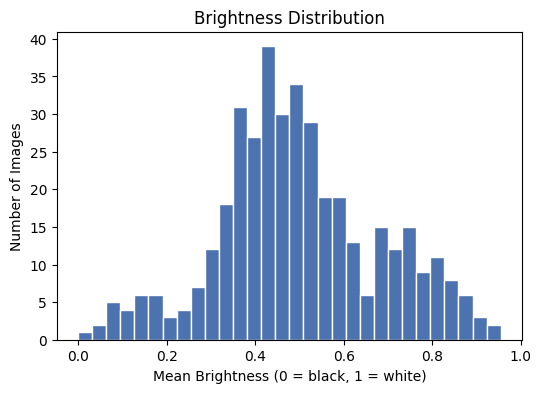

In [5]:
# === Brightness distribution ===
# For every image, compute the mean brightness (average over all
# pixels, normalised to [0, 1]) and draw a histogram. This reveals
# whether the dataset contains very dark or very bright outliers
# that would require intensity correction.

# Average brightness per image
brightness = []

# Walk over all class folders again.
for label in os.listdir(SOURCE_DIR):
    class_path = os.path.join(SOURCE_DIR, label)

    if not os.path.isdir(class_path):
        continue

    for file in os.listdir(class_path):
        # Only process files with an allowed extension.
        if not file.lower().endswith(TF_ALLOWED_EXT):
            continue

        path = os.path.join(class_path, file)

        try:
            # Open the image, convert to RGB and turn it into a numpy array.
            # Dividing by 255 normalises pixel values to [0, 1].
            with Image.open(path) as img:
                img = img.convert("RGB")
                arr = np.array(img, dtype=np.float32) / 255.0
                # Mean over all pixels and channels = mean brightness.
                brightness.append(arr.mean())

        except Exception as e:
            # Skip broken images instead of crashing the whole run.
            print(f"Error reading {path}: {e}")

# Histogram of the collected brightness values.
plt.figure(figsize=(6, 4))
plt.hist(brightness, bins=30, color="#4C72B0", edgecolor="white")
plt.title("Brightness Distribution")
plt.xlabel("Mean Brightness (0 = black, 1 = white)")
plt.ylabel("Number of Images")
plt.show()

### 4.4 Image sizes


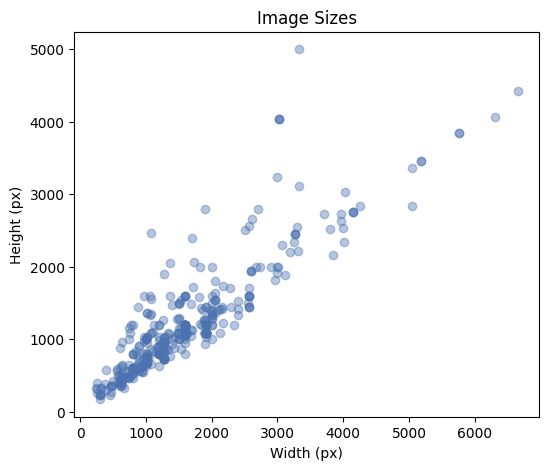

In [6]:
# === Distribution of image sizes ===
# Collect every image resolution to see how heterogeneous the dataset
# is. Since the model has a fixed input size (224x224), all images
# will be resized anyway -> but extreme aspect ratios can cause
# distortions during resizing.

sizes = []

# Iterate over all classes.
for label in os.listdir(SOURCE_DIR):
    class_path = os.path.join(SOURCE_DIR, label)

    if not os.path.isdir(class_path):
        continue

    for file in os.listdir(class_path):
        path = os.path.join(class_path, file)

        try:
            # img.size returns a tuple (width, height).
            with Image.open(path) as img:
                sizes.append(img.size)

        except Exception:
            # Report broken files but keep going.
            print(f"Failed to load: {path}")

# Split widths and heights into separate lists for the scatter plot.
widths = [s[0] for s in sizes]
heights = [s[1] for s in sizes]

# Scatter plot: every point is one image (width vs. height).
plt.figure(figsize=(6, 5))
plt.scatter(widths, heights, alpha=0.4, color="#4C72B0")
plt.xlabel("Width (px)")
plt.ylabel("Height (px)")
plt.title("Image Sizes")
plt.show()

**Observations.** The two classes are roughly balanced. Images come in a wide range of resolutions and aspect ratios, so resizing every image to a fixed 224&times;224 input (as the model expects) is necessary. Brightness varies but is mostly centred around mid-grey values, so we do not need any aggressive intensity correction beyond the standard `Rescaling(1/255)` layer.


## 5. Train / validation / test split

We use a 70 / 15 / 15 split. The old `data_split` folder is deleted first so that no stale or already-removed files survive in the new split.


In [7]:
# === Train/val/test split ===
# Split the dataset into 70 % train, 15 % validation and 15 % test.
# Any existing split folder is removed first so that stale files from
# earlier runs do not contaminate the new split.

# If an old split already exists -> remove it completely.
if os.path.exists(SPLIT_DIR):
    shutil.rmtree(SPLIT_DIR)
    print("Removed old split folder:", SPLIT_DIR)

# splitfolders automatically creates train/val/test sub-folders with
# the same class structure as the source directory.
splitfolders.ratio(
    SOURCE_DIR,
    output=SPLIT_DIR,
    seed=SEED,                  # reproducibility
    ratio=(0.7, 0.15, 0.15),    # 70 / 15 / 15 split
)

print("Split finished.")

Removed old split folder: data_split
Split finished.


### 5.1 Safety check after the split


In [8]:
# Safety net: if an unusable file accidentally made it into the
# split during copying, run the same cleanup function on the split
# folder once more.
remove_invalid_images_for_tensorflow(SPLIT_DIR)

Valid images checked: 396
Total removed: 0


## 6. Build the TensorFlow datasets

We load each split into a `tf.data.Dataset`. The labels are stored as binary (0 = first class, 1 = second class). Train and validation datasets are shuffled and cached for speed, the test set is **not** shuffled so that predictions stay aligned with labels when we compute the confusion matrix later.


In [9]:
# === Build TensorFlow datasets from the image folders ===
# image_dataset_from_directory reads images directly from the folder
# structure (one sub-folder = one class) and returns pre-batched and
# resized tensors.
# label_mode="binary" returns labels as 0/1 (matching the sigmoid
# output and binary_crossentropy loss further down).

# Training data: shuffled (shuffle is enabled internally because seed is set).
train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(SPLIT_DIR, "train"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    seed=SEED,
)

# Validation data: also shuffled, but separate from the training set.
val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(SPLIT_DIR, "val"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    seed=SEED,
)

# Test data: IMPORTANT shuffle=False, so that the order of the
# predictions matches the order of the true labels exactly
# (crucial for the confusion matrix further down).
test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(SPLIT_DIR, "test"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False,
)

# Class names are derived from the folder names (alphabetically).
class_names = train_ds.class_names
print("Class names:", class_names)

Found 276 files belonging to 2 classes.
Found 59 files belonging to 2 classes.
Found 61 files belonging to 2 classes.
Class names: ['bicycle', 'motorcycle']


In [10]:
# === Performance optimisations for the tf.data pipelines ===
# - cache():    keeps already-loaded images in RAM, saves read time from epoch 2 onward
# - shuffle():  reshuffles the training data every epoch (buffer = 1000)
# - prefetch(): prepares the next batch in parallel with the current GPU computation
# AUTOTUNE lets TensorFlow choose the optimal parallelism on its own.

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000, seed=SEED).prefetch(AUTOTUNE)
# Validation and test are NOT shuffled -> reproducible metrics.
val_ds = val_ds.cache().prefetch(AUTOTUNE)
test_ds = test_ds.cache().prefetch(AUTOTUNE)

## 7. Baseline CNN

Our first model is a small CNN trained from scratch. The architecture is intentionally simple so that we have a clear baseline to compare the transfer-learning model against.

**Architecture choices:**

- `Rescaling(1./255)` is placed *inside* the model. This way the model owns its own preprocessing and we do not have to remember to rescale at inference time.
- A small `data_augmentation` block (horizontal flip, slight rotation and zoom) is active only during training. This is a cheap form of regularization that helps with a relatively small dataset.
- Two `Conv2D + MaxPooling` blocks extract local features and reduce spatial resolution.
- A `Dense(64)` head with `Dropout(0.3)` performs the classification. Dropout is the main explicit regularizer to fight overfitting.
- The output layer has a single neuron with `sigmoid` activation, matching the `binary_crossentropy` loss and binary labels.
- Optimizer: **Adam** with a learning rate of `1e-3`. Adam adapts the per-parameter learning rate and is a robust default for small CNNs.


In [11]:
# === Data augmentation ===
# A small block of random image transformations that is only active
# during training (Keras automatically disables it during
# model.evaluate / model.predict).
# This effectively enlarges the training set and acts as a
# regulariser against overfitting.

data_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip("horizontal"),  # random horizontal flips
        tf.keras.layers.RandomRotation(0.05),      # rotation up to +/- 5 % of 2*pi
        tf.keras.layers.RandomZoom(0.1),           # random zoom in/out
    ],
    name="data_augmentation",
)

In [12]:
# === Define and compile the baseline CNN ===
# Kept deliberately small so it serves as an honest comparison
# baseline against the transfer-learning model.

model = tf.keras.Sequential([
    # Input: 224x224 RGB images.
    tf.keras.layers.Input(shape=(224, 224, 3)),

    # Scale pixel values from 0-255 to 0-1
    # Doing the scaling inside the model means it is also active at inference time.
    tf.keras.layers.Rescaling(1.0 / 255),

    # Data augmentation is only active during training
    # (block defined above).
    data_augmentation,

    # First feature-extractor block: 32 filters, then pooling halves the spatial resolution.
    tf.keras.layers.Conv2D(32, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    # Second block: 64 filters -> can capture more complex patterns.
    tf.keras.layers.Conv2D(64, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    # Classification head: feature map -> vector -> dense layer -> dropout -> output.
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dropout(0.3),                       # regularisation against overfitting
    tf.keras.layers.Dense(1, activation="sigmoid"),     # 1 neuron + sigmoid = binary probability
])

# Compile: Adam optimiser + binary cross-entropy matching the sigmoid output.
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

# Quick overview of the layers and parameter count.
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 186624)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │    11,944,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,963,457 (45.64 MB)

 Trainable params: 11,963,457 (45.64 MB)

 Non-trainable params: 0 (0.00 B)

## 8. Train the baseline


In [13]:
# === Train the baseline model ===
# fit() returns a history object containing the per-epoch metrics,
# which are used to plot the learning curves below.
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
)

Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 363ms/step - accuracy: 0.3776 - loss: 4.7024 - val_accuracy: 0.4068 - val_loss: 0.7441
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 337ms/step - accuracy: 0.5301 - loss: 0.7172 - val_accuracy: 0.5932 - val_loss: 0.6565
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 329ms/step - accuracy: 0.6441 - loss: 0.6691 - val_accuracy: 0.5932 - val_loss: 0.6069
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 327ms/step - accuracy: 0.5846 - loss: 0.6704 - val_accuracy: 0.5932 - val_loss: 0.6323
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 337ms/step - accuracy: 0.5325 - loss: 0.6833 - val_accuracy: 0.5932 - val_loss: 0.6022
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 331ms/step - accuracy: 0.5838 - loss: 0.6307 - val_accuracy: 0.5932 - val_loss: 0.5801
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 328ms/step - accuracy: 0.5760 - loss: 0.5904 - val_accuracy: 0.6102 - val_loss: 0.7482
Epoch 8/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 346ms/step - accuracy: 0.6514 - loss: 0.5676 - val_accuracy: 0.6610 - val_loss:

### 8.1 Training curves


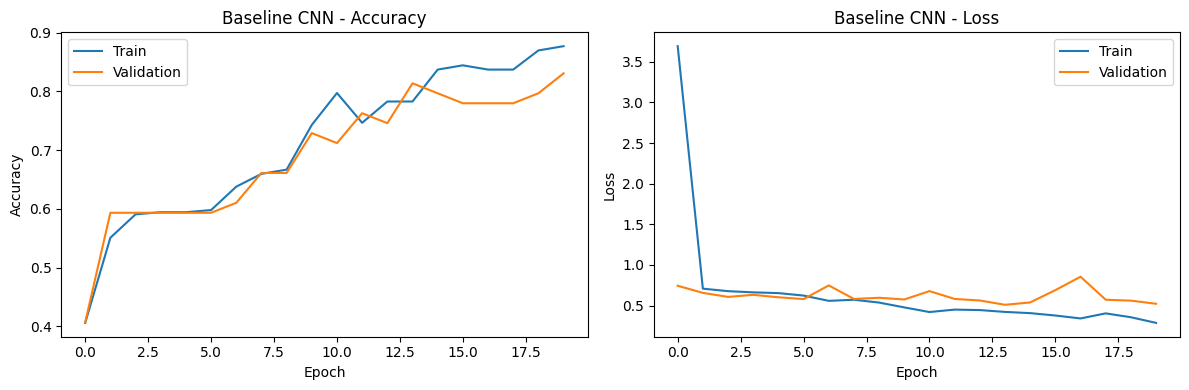

In [14]:
# === Learning curves of the baseline CNN ===
# Two subplots: accuracy on the left, loss on the right, each shown
# for training and validation. If the training curve gets much
# better than the validation curve, that's a sign of overfitting.

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left plot: accuracy over epochs.
axes[0].plot(history.history["accuracy"], label="Train")
axes[0].plot(history.history["val_accuracy"], label="Validation")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Baseline CNN - Accuracy")
axes[0].legend()

# Right plot: loss over epochs.
axes[1].plot(history.history["loss"], label="Train")
axes[1].plot(history.history["val_loss"], label="Validation")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].set_title("Baseline CNN - Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

## 9. Evaluation on the test set

The test set is only used here, after training is finished, as the final independent performance estimate.


In [15]:
# === Final evaluation on the test set (baseline) ===
# The test set was never seen during training and therefore gives
# an unbiased estimate of the generalisation performance.
test_loss, test_acc = model.evaluate(test_ds)
print(f"Baseline test loss:     {test_loss:.4f}")
print(f"Baseline test accuracy: {test_acc:.4f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step - accuracy: 0.6783 - loss: 0.8242
Baseline test loss:     0.7369
Baseline test accuracy: 0.7049


### 9.1 Confusion matrix

The confusion matrix shows where the model gets confused: are mistakes symmetric (equally many bicycles labelled as motorcycles and vice versa), or is one direction more common?


Confusion matrix:
[[16  9]
 [ 9 27]]


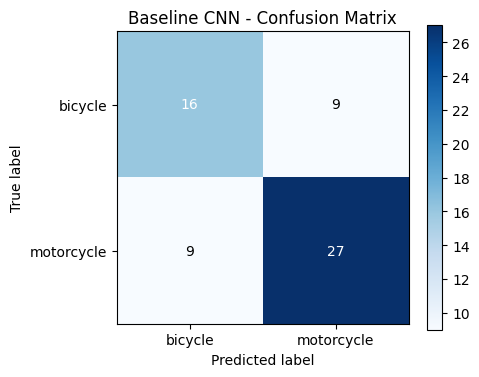

In [16]:
# === Confusion matrix of the baseline ===
# Collect true labels and predicted classes per batch in order to
# build the 2x2 confusion matrix.

y_true = []   # list of actual labels
y_pred = []   # list of predicted labels

# Iterate over all test batches (order is stable because shuffle=False).
for images, labels in test_ds:
    # The model outputs probabilities in [0, 1].
    probs = model.predict(images, verbose=0)
    # Threshold of 0.5: anything above is interpreted as class 1.
    preds = (probs >= 0.5).astype(int).flatten()

    # Append the numpy arrays to flat Python lists.
    y_true.extend(labels.numpy().astype(int).flatten())
    y_pred.extend(preds)

# TensorFlow computes the matrix; .numpy() converts it to a normal numpy array.
cm = tf.math.confusion_matrix(y_true, y_pred, num_classes=2).numpy()
print("Confusion matrix:")
print(cm)

# Heatmap visualisation of the confusion matrix.
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_title("Baseline CNN - Confusion Matrix")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(class_names)
ax.set_yticklabels(class_names)

# Write the counts directly into the cells. White text on dark
# cells, black text on light cells -> good readability.
thresh = cm.max() / 2
for i in range(2):
    for j in range(2):
        color = "white" if cm[i, j] > thresh else "black"
        ax.text(j, i, cm[i, j], ha="center", va="center", color=color)

# Colorbar and tidy layout.
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

## 10. Transfer learning with MobileNetV2

Training a CNN from scratch on a small dataset rarely produces strong results. A standard fix is **transfer learning**: take a model pretrained on a large dataset (ImageNet, ~1.3M images, 1000 classes) and adapt only the final layers to the new task.

We use **MobileNetV2**: it is lightweight, fast on a laptop CPU, and ImageNet-pretrained weights are available out of the box in Keras.

**Setup:**

- Load MobileNetV2 without its classification head (`include_top=False`).
- Freeze the backbone so its pretrained features are kept as-is.
- Add our own small classification head: `GlobalAveragePooling2D` &rarr; `Dropout(0.3)` &rarr; `Dense(1, sigmoid)`.
- Use a **lower learning rate** (`1e-4`). With pretrained features we only need small updates; a high learning rate could destroy useful filters.


In [17]:
# === Load the pretrained MobileNetV2 as a feature extractor ===
# include_top=False drops the original ImageNet classification head;
# weights="imagenet" loads the pretrained weights from ImageNet.
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet",
)

# Freeze the backbone: the pretrained weights are NOT updated at
# first; only the new head will be trained.
base_model.trainable = False

In [18]:
# === Assemble the transfer-learning model ===
# Wrap the frozen MobileNetV2 between the proper preprocessing and a
# small, freshly trained classification head.

# preprocess_input for MobileNetV2 scales pixel values to [-1, 1].
preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

transfer_model = tf.keras.Sequential([
    # Same input shape as the baseline model.
    tf.keras.layers.Input(shape=(224, 224, 3)),
    # Same augmentation block as above (only active during training).
    data_augmentation,
    # MobileNetV2 expects inputs scaled to [-1, 1], not [0, 1]
    # The Lambda layer applies the official preprocessing function.
    tf.keras.layers.Lambda(preprocess_input),

    # Pretrained feature extractor (frozen).
    base_model,

    # Classification head:
    # - GlobalAveragePooling reduces the feature map to a single vector (small, robust).
    # - Dropout reduces overfitting.
    # - Dense(1, sigmoid) returns the binary probability.
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1, activation="sigmoid"),
])

# Print a summary of all layers.
transfer_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [19]:
# Compile with a smaller learning rate (1e-4):
# In transfer learning we want to train the head without destroying
# the pretrained features. A small learning rate is the safe default
# for this.
transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

In [20]:
# === Train the transfer model ===
# Only the new head is learned, the backbone stays frozen.
history_transfer = transfer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
)

Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 7s 429ms/step - accuracy: 0.6350 - loss: 0.6255 - val_accuracy: 0.7797 - val_loss: 0.5459
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 325ms/step - accuracy: 0.6967 - loss: 0.5704 - val_accuracy: 0.7458 - val_loss: 0.5327
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 320ms/step - accuracy: 0.7744 - loss: 0.5449 - val_accuracy: 0.7288 - val_loss: 0.5220
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 318ms/step - accuracy: 0.7481 - loss: 0.4933 - val_accuracy: 0.7458 - val_loss: 0.5084
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 321ms/step - accuracy: 0.7403 - loss: 0.5055 - val_accuracy: 0.7627 - val_loss: 0.4958
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 318ms/step - accuracy: 0.7806 - loss: 0.4967 - val_accuracy: 0.7627 - val_loss: 0.4809
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 319ms/step - accuracy: 0.8140 - loss: 0.4744 - val_accuracy: 0.7966 - val_loss: 0.4673
Epoch 8/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 317ms/step - accuracy: 0.8149 - loss: 0.4742 - val_accuracy: 0.8136 - val_loss:

### 10.1 Training curves &mdash; transfer model


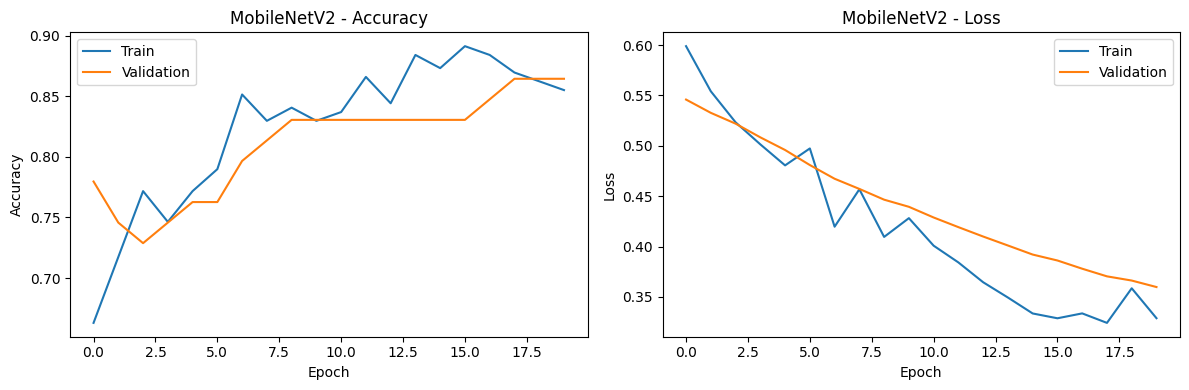

In [21]:
# === Learning curves of the transfer model ===
# Same plotting layout as for the baseline so the two models can be
# compared directly.

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy curves.
axes[0].plot(history_transfer.history["accuracy"], label="Train")
axes[0].plot(history_transfer.history["val_accuracy"], label="Validation")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("MobileNetV2 - Accuracy")
axes[0].legend()

# Loss curves.
axes[1].plot(history_transfer.history["loss"], label="Train")
axes[1].plot(history_transfer.history["val_loss"], label="Validation")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].set_title("MobileNetV2 - Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

### 10.2 Test-set evaluation &mdash; transfer model


In [22]:
# === Test performance of the transfer model ===
# Again evaluated on the test set that was unseen during training.
transfer_test_loss, transfer_test_acc = transfer_model.evaluate(test_ds)

print(f"Transfer learning test loss:     {transfer_test_loss:.4f}")
print(f"Transfer learning test accuracy: {transfer_test_acc:.4f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 245ms/step - accuracy: 0.8610 - loss: 0.4049
Transfer learning test loss:     0.3484
Transfer learning test accuracy: 0.8852


## 11. Experiments and model comparison

We collect the results of all trained models in one table to make the comparison explicit.

In [23]:
# === Comparison table of all experiments ===
# Collect hyperparameters and test metrics in a list of dictionaries
# and turn it into a DataFrame. This makes side-by-side comparisons
# of the models easy to read.

import pandas as pd

experiment_results = [
    {
        "model": "Baseline CNN",
        "learning_rate": 0.001,
        "dropout": 0.3,
        "epochs": EPOCHS,
        "test_accuracy": float(test_acc),          # from the baseline evaluation
        "notes": "Trained from scratch.",
    },
    {
        "model": "MobileNetV2 (frozen)",
        "learning_rate": 0.0001,
        "dropout": 0.3,
        "epochs": EPOCHS,
        "test_accuracy": float(transfer_test_acc), # from the transfer evaluation
        "notes": "Weights frozen, head is trained.",
    }
]

# Build the DataFrame; Jupyter renders it nicely without an explicit print().
results_df = pd.DataFrame(experiment_results)
results_df

,model,learning_rate,dropout,epochs,test_accuracy,notes
0,Baseline CNN,0.0010,0.3,20,0.704918,Trained from scratch.
1,MobileNetV2 (frozen),0.0001,0.3,20,0.885246,"Weights frozen, head is trained."


## 12. Fine-tuning the top layers of MobileNetV2

If the frozen transfer model is already strong, fine-tuning the **last few** layers of MobileNetV2 sometimes squeezes out a bit more accuracy. We unfreeze only the top of the backbone and continue training with a much smaller learning rate, so the pretrained weights are nudged rather than overwritten.

This is kept short on purpose: it is one extra experiment, not a separate project.


In [24]:
# === Fine-tune the top layers of MobileNetV2 ===
# Idea: make the top ~30 layers of the backbone trainable while
# keeping the earlier layers frozen. Using a very small learning
# rate (1e-5) only nudges the pretrained weights instead of
# overwriting them.

# Unfreeze only the top portion of the backbone
# First unfreeze everything, then re-freeze the lower layers selectively.
base_model.trainable = True
FINE_TUNE_AT = len(base_model.layers) - 30  # last ~30 layers become trainable
for layer in base_model.layers[:FINE_TUNE_AT]:
    layer.trainable = False

# Recompile with a much lower learning rate after changing trainable flags
# After changing the trainable flags the model MUST be recompiled, so
# that the optimiser picks up the new set of trainable variables.
transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

# Shorter fine-tuning run to avoid overfitting.
FINE_TUNE_EPOCHS = 5
history_finetune = transfer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=FINE_TUNE_EPOCHS,
)

# Final evaluation of the fine-tuned model on the test set.
ft_test_loss, ft_test_acc = transfer_model.evaluate(test_ds)
print(f"Fine-tuned test loss:     {ft_test_loss:.4f}")
print(f"Fine-tuned test accuracy: {ft_test_acc:.4f}")

Epoch 1/5
9/9 ━━━━━━━━━━━━━━━━━━━━ 11s 478ms/step - accuracy: 0.8247 - loss: 0.4023 - val_accuracy: 0.8475 - val_loss: 0.3357
Epoch 2/5
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 367ms/step - accuracy: 0.8387 - loss: 0.3918 - val_accuracy: 0.8644 - val_loss: 0.3125
Epoch 3/5
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 375ms/step - accuracy: 0.8607 - loss: 0.3514 - val_accuracy: 0.8644 - val_loss: 0.2938
Epoch 4/5
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 368ms/step - accuracy: 0.8867 - loss: 0.3152 - val_accuracy: 0.8814 - val_loss: 0.2787
Epoch 5/5
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 361ms/step - accuracy: 0.9326 - loss: 0.2482 - val_accuracy: 0.8814 - val_loss: 0.2650
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - accuracy: 0.8823 - loss: 0.2678
Fine-tuned test loss:     0.2363
Fine-tuned test accuracy: 0.9016


### 12.1 Updated model comparison

With the fine-tuned model trained, we can now extend the comparison table from Section 11 with the final result.

In [ ]:
# === Add the fine-tuned model to the comparison table ===
# The comparison table above was built before fine-tuning happened, so it
# only contained two rows. We append the third experiment here so the
# table in this notebook always reflects the actual numbers produced by
# the cells above (no hand-copied numbers).
experiment_results.append({
    "model": "MobileNetV2 (fine-tuned)",
    "learning_rate": 1e-5,
    "dropout": 0.3,
    "epochs": FINE_TUNE_EPOCHS,
    "test_accuracy": float(ft_test_acc),
    "notes": "Top ~30 layers of MobileNetV2 unfrozen and fine-tuned.",
})

results_df = pd.DataFrame(experiment_results)
results_df

## 13. Problems encountered

Things that went wrong during the project and how we solved them:

- **Corrupted / unsupported image files.** The raw folder contained `.webp` files and some `.jpg` files that were not actually decodable images. `tf.keras.utils.image_dataset_from_directory` then crashed with `Unknown image file format`. We fixed this by delete all `.webp` files.
- **Different image sizes and aspect ratios.** We rely on the dataset loader to resize everything to 224&times;224. This can squash images with very wide or very tall aspect ratios.

## 14. Further work

Possible next steps if more time were available:

- **More data and harder examples.** Many real-world failure cases probably come from unusual angles, partial occlusion, or scooters / e-bikes that sit between the two classes. A larger, more diverse dataset would directly help.
- **Stronger data augmentation.** Brightness / contrast jitter, random crops and `MixUp` could improve robustness on the small dataset.
- **Systematic hyperparameter search** using Keras Tuner or Optuna (learning rate, dropout rate, number of dense units, number of fine-tuned layers).
- **Early stopping and learning-rate scheduling** via Keras callbacks, to avoid training too long or with a too-high learning rate.
- **Class activation maps (Grad-CAM)** to inspect *what* the model looks at when it predicts "bicycle" or "motorcycle". This often reveals shortcut learning.


## 15. Evaluation and Conclusion

The best performing model in this project was the **MobileNetV2 model with fine-tuning**, achieving a **test accuracy of 90.2 %** with a **test loss of 0.236**. The comparison between all tested models clearly shows the benefit of transfer learning:

| Model | Test Accuracy | Test Loss |
|---|---|---|
| Baseline CNN | 70.5 % | 0.7369 |
| MobileNetV2 (frozen) | 88.5 % | 0.3484 |
| MobileNetV2 (fine-tuned) | 90.2 % | 0.2363 |

The baseline CNN trained from scratch achieved only moderate performance, most likely because the dataset was relatively small. In contrast, transfer learning with a pretrained MobileNetV2 significantly improved the results. Even with frozen layers, the pretrained model already achieved 88.5 % accuracy, demonstrating that ImageNet-pretrained features such as edges, wheels, textures, and object shapes transfer very effectively to the bicycle vs. motorcycle classification task.

Fine-tuning the top layers of the pretrained network further improved the performance by approximately 1.6 percentage points and reduced the loss substantially. This indicates that the model not only classified images more accurately, but also produced more confident predictions. The fine-tuned model was therefore selected as the final model.

During training, slight signs of overfitting became visible in the final epochs of the fine-tuning phase. The training accuracy continued to increase while the validation accuracy improved more slowly, suggesting that the model started adapting too strongly to the training data. Early stopping or additional regularization techniques could likely improve generalization further.

One limitation of this project is the relatively small dataset size. A larger and more diverse dataset would likely improve robustness and reduce overfitting. Another possible improvement would be the use of learning-rate scheduling and systematic hyperparameter tuning.

Overall, the project demonstrates that transfer learning is highly effective for image classification tasks with limited data. The pretrained MobileNetV2 model clearly outperformed the custom CNN architecture and achieved strong classification performance for distinguishing bicycles from motorcycles.